# Decision models: one pass, no decoding, honest probabilities

**The whole idea in one sentence:** a decision model is a transformer that runs once
and reads probabilities off the answers you allowed instead of sampling a token —
and RLCD is training those probabilities with a reward that only honesty can win.

The attention notebook built the block that moves information between tokens; the
activations notebook built the block that bends it. This one takes a finished
backbone and asks a different question of it: not *what comes next*, but *which of
these*. That question is what TypeSafe's Jev answers, what Cloudflare's Clef, AWS's
Strands Decider and a dozen open clones answer, and what the repo's
[decision-model roadmap](../../docs/decision-model.md) is for.

By the end you'll have:

- turned the **same five logits** into a generated token and into a decision, and seen
  why one of them can never leave the schema
- computed the three primitives — **choice, score, noul** — and the `confidence` and
  `score` numbers from TypeSafe's docs, to the digit
- written a ticket generator whose **label frequencies you choose**, so that "honest"
  has a number you can check against
- built a pointer head that scores options by their hidden states, trained it, and
  watched it report **0.6 where you wrote 0.6**
- scored five tickets under two rewards by hand and found that **one of them cannot
  tell 0.6 from 1.0**, and that this is the whole of RLCD
- cleaned the labels, the way a careful annotator would, and watched the model become
  **confidently wrong**; overtrained it and watched a single number, the temperature, put
  it back
- measured honesty three ways — ECE with its noise floor, and **coverage at a fixed error
  budget**, the number temperature scaling cannot touch
- asked three questions in one pass and caught the second one **reading the first**,
  then fixed it with a block mask and restarted positions
- tried the other readout, single-token labels, and found it **still at chance** after the
  epochs the pointer head needed to learn the task — then trained with the options in a
  fixed order and watched accuracy halve when they moved

In [1]:
import math
import random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
random.seed(0)
np.set_printoptions(precision=3, suppress=True, linewidth=110)
torch.set_printoptions(precision=3, sci_mode=False, linewidth=110)

try:
    import matplotlib.pyplot as plt
    HAVE_MPL = True
except ImportError:
    HAVE_MPL = False
    print("matplotlib not installed - plot cells will print a note instead (uv sync --extra demo)")

SURFACE, INK, INK2, GRID = "#fcfcfb", "#1f1e1d", "#6b6a63", "#e8e7e3"
BLUE, ORANGE, AQUA, YELLOW, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"

def style(ax):
    ax.set_facecolor(SURFACE); ax.set_axisbelow(True)
    ax.grid(color=GRID, lw=0.6)
    ax.tick_params(colors=INK2, labelsize=8)
    for s in ax.spines.values():
        s.set_visible(False)

---
## 1. Generate, or decide

A language model ends every forward pass with one number per vocabulary entry. Take a
vocabulary of five — `A`, `B`, `C`, `yes`, `no` — and a prompt that ends in
`Which department? A=billing B=technical C=other. Answer:`. The last position produces
five logits. What happens next is the entire difference between the two kinds of model.

In [2]:
vocab5 = ["A", "B", "C", "yes", "no"]
logits = torch.tensor([2.0, 0.1, -0.5, 1.4, 0.3])        # what the last position produced

# the language-model path: softmax over everything, sample one, append it, run again
p_all = logits.softmax(0)
g = torch.Generator().manual_seed(1)
picked = torch.multinomial(p_all, 1, generator=g).item()
print("LM   softmax over all five:", {w: round(v, 3) for w, v in zip(vocab5, p_all.tolist())})
print("     sampled token:", repr(vocab5[picked]), "  -> append it, run the model again, repeat")

# the decision-model path: keep only the allowed answers, softmax those, stop
allowed = [0, 1, 2]                                         # A, B, C
p = logits[allowed].softmax(0)
print("\nDM   softmax over A, B, C only:", {w: round(v, 3) for w, v in zip(["billing", "technical", "other"], p.tolist())})
print("     answer: billing   -> done. no sampling, no second pass, nothing to parse")

LM   softmax over all five: {'A': 0.509, 'B': 0.076, 'C': 0.042, 'yes': 0.28, 'no': 0.093}
     sampled token: 'A'   -> append it, run the model again, repeat

DM   softmax over A, B, C only: {'billing': 0.812, 'technical': 0.121, 'other': 0.067}
     answer: billing   -> done. no sampling, no second pass, nothing to parse


Same five numbers. The language model turns them into a token and has to run again to
produce the next one; a `yes` is as legal an answer as a `C`, and so is any token the
prompt never mentioned. The decision model keeps three of the five, normalises them and
stops. **It cannot answer `D` or `yes` or `ask Sarah`, because they were never in the
softmax.** That is all "zero hallucination" means for these models: zero answers outside
the schema. Putting 0.81 on the wrong department is still allowed, and still happens.

The speed story is the same picture. Generating a word is a loop of forward passes, one
per token. Deciding is the first pass of that loop with the loop removed.

### The three primitives

Every decision API that has shipped exposes the same three question types, and they are
three readings of the same softmax:

| type | question | what comes back |
|---|---|---|
| `choice` | which of these? | a probability per option, the top one named, and a `confidence` |
| `score` | where on this ordered scale? | a probability per level, a `score`, and a `confidence` |
| `noul` | is this true? | one number: the probability of *yes* |

`score` and `confidence` are not model outputs. They are arithmetic on the distribution,
and TypeSafe documents both formulas, with a worked example we can hit to the digit:

In [3]:
def confidence_choice(p):
    # how far the top probability sits above an even split: 0 for uniform, 1 for a point mass
    n = len(p)
    return (p.max() - 1 / n) / (1 - 1 / n)

def score_value(p):
    # probability-weighted level index; fractional on purpose
    return sum(i * pi for i, pi in enumerate(p))

def confidence_score(p):
    # 1 minus the expected distance from the modal level, relative to the same distance under uniform:
    # mass on an adjacent level costs less than mass on the far end
    m = int(torch.as_tensor(p).argmax())
    dist = sum(pi * abs(i - m) for i, pi in enumerate(p))
    mad_uniform = sum(abs(i - m) for i in range(len(p))) / len(p)
    return max(0.0, 1 - dist / mad_uniform)

# the example from docs.typesafe.ai/primitives/score: three severity levels
p_sev = torch.tensor([0.0, 0.57, 0.43])
print(f"score      = 0·0.00 + 1·0.57 + 2·0.43 = {score_value(p_sev):.2f}      (docs: 1.43)")
print(f"confidence = {confidence_score(p_sev):.3f}                           (docs: 0.35)")

p_dept = torch.tensor([0.81, 0.12, 0.07])
print(f"\nchoice confidence for {[round(v, 2) for v in p_dept.tolist()]}: ({p_dept.max():.2f} - 1/3) / (1 - 1/3) = {confidence_choice(p_dept):.2f}")
print(f"the same top probability over 10 options would score {((0.81 - 0.1) / 0.9):.2f} - confidence is scale-free, p_max is not")

score      = 0·0.00 + 1·0.57 + 2·0.43 = 1.43      (docs: 1.43)
confidence = 0.355                           (docs: 0.35)

choice confidence for [0.81, 0.12, 0.07]: (0.81 - 1/3) / (1 - 1/3) = 0.71
the same top probability over 10 options would score 0.79 - confidence is scale-free, p_max is not


1.43 and 0.355, which the docs print as 0.35. The point of `confidence` is that 0.81 means
something different over three options than over ten, and software gating on a threshold
needs one scale. The point of `score` being fractional is that a model 57/43 between two
adjacent severities is telling you something a hard label would throw away.

---
## 2. Tickets whose answers we chose

To check whether a model's probabilities are honest you need to know what honest *is*.
Real datasets never tell you: a ticket is labelled `billing`, not `billing with
probability 0.6`. So we generate the tickets, and we write the frequencies in ourselves.

Three questions per ticket:

- **department** (`choice`, four options): one keyword from the department's list makes it
  unambiguous. A quarter of tickets instead say `charged twice` and carry no keyword —
  and for those, by construction, the label is `billing` **60%** of the time and
  `account` 40%. The text is identical either way. An honest model has to say 0.6.
- **urgency** (`score`, three levels): `today` → 2, `soon` → 1, nothing → 0. Deterministic;
  an honest model should be certain.
- **angry** (`noul`): two or more `!` → yes with probability **0.9**, otherwise 0.1.

Every ticket also records its *true* distribution per question, which is what we will hold
the model to.

In [4]:
DEPTS = ["billing", "technical", "account", "other"]
KEYWORDS = {
    "billing":   ["invoice", "refund", "payment", "receipt"],
    "technical": ["crash", "error", "bug", "slow"],
    "account":   ["login", "password", "locked", "profile"],
    "other":     ["question", "feedback", "hello", "thanks"],
}
FILLER = ["the", "my", "please", "app", "it", "is", "and", "help", "again", "now"]
URGENCY = ["can wait", "soon", "today"]

def make_ticket(rng, p_ambiguous=0.25):
    words = rng.sample(FILLER, rng.randint(2, 4))
    if rng.random() < p_ambiguous:                        # the region where the answer is genuinely 60/40
        words += ["charged", "twice"]
        p_dept = [0.6, 0.0, 0.4, 0.0]
    else:
        d = rng.randrange(4)
        words += [rng.choice(KEYWORDS[DEPTS[d]])]
        p_dept = [0.0] * 4; p_dept[d] = 1.0
    r = rng.random()
    level = 2 if r < 0.3 else 1 if r < 0.6 else 0
    words += {2: ["today"], 1: ["soon"], 0: []}[level]
    p_urg = [0.0] * 3; p_urg[level] = 1.0
    bangs = rng.choice([0, 1, 2, 3])
    words += ["!"] * bangs
    p_yes = 0.9 if bangs >= 2 else 0.1
    rng.shuffle(words)
    truth = {"department": p_dept, "urgency": p_urg, "angry": [1 - p_yes, p_yes]}
    label = {q: rng.choices(range(len(pq)), weights=pq)[0] for q, pq in truth.items()}   # one draw from the truth
    return {"words": words, "truth": truth, "label": label, "ambiguous": "charged" in words}

rng = random.Random(0)
tickets = [make_ticket(rng) for _ in range(6000)]
train_t, cal_t, test_t = tickets[:4000], tickets[4000:5000], tickets[5000:]

for t in tickets[:4]:
    print(" ".join(t["words"]))
    print("   truth:", {q: [round(v, 1) for v in p] for q, p in t["truth"].items()}, " label:", t["label"])
amb_train = [t for t in train_t if t["ambiguous"]]
print(f"\n{len(amb_train)} of {len(train_t)} training tickets are ambiguous; their labels are billing {sum(t['label']['department'] == 0 for t in amb_train) / len(amb_train):.0%} of the time")

! and ! the it thanks
   truth: {'department': [0.0, 0.0, 0.0, 1.0], 'urgency': [1.0, 0.0, 0.0], 'angry': [0.1, 0.9]}  label: {'department': 3, 'urgency': 0, 'angry': 1}
! today please charged it again twice !
   truth: {'department': [0.6, 0.0, 0.4, 0.0], 'urgency': [0.0, 0.0, 1.0], 'angry': [0.1, 0.9]}  label: {'department': 2, 'urgency': 2, 'angry': 1}
now the again charged twice
   truth: {'department': [0.6, 0.0, 0.4, 0.0], 'urgency': [1.0, 0.0, 0.0], 'angry': [0.9, 0.1]}  label: {'department': 2, 'urgency': 0, 'angry': 0}
and ! ! app ! invoice please now
   truth: {'department': [1.0, 0.0, 0.0, 0.0], 'urgency': [1.0, 0.0, 0.0], 'angry': [0.1, 0.9]}  label: {'department': 0, 'urgency': 0, 'angry': 1}

1019 of 4000 training tickets are ambiguous; their labels are billing 61% of the time


The last line is the dataset telling the truth about itself: the ambiguous tickets came out
`billing` about 60% of the time, because that is the number we wrote. Nothing in a single
ticket says 0.6. Only the collection does.

### A request as one sequence

A state and a question have to become one token sequence. The layout, which is what Kev and
AWS's Strands Decider use and what the API evidence says Jev does:

```
<state> words … <q> department <opt> billing </opt> <opt> technical </opt> <opt> account </opt> <opt> other </opt> <decide>
```

The state first, then a question marker and the question's name, each option wrapped in
`<opt> … </opt>`, and a `<decide>` token at the end. The markers are reserved tokens, so no
text in the state can forge an option boundary. Every option order is a permutation, drawn
fresh for every record; section 8 shows what happens if you don't.

In [5]:
SPECIAL = ["<pad>", "<state>", "<q>", "<opt>", "</opt>", "<decide>"]
LABELS = ["A", "B", "C", "D"]                                  # not used until section 8
QNAMES = ["department", "urgency", "angry"]
OPTIONS = {"department": DEPTS, "urgency": URGENCY, "angry": ["no", "yes"]}
WORDS = sorted({w for d in KEYWORDS.values() for w in d} | set(FILLER) | {"charged", "twice", "today", "soon", "!"})
OPTION_WORDS = sorted({o for opts in OPTIONS.values() for o in opts})
VOCAB = SPECIAL + LABELS + QNAMES + WORDS + OPTION_WORDS
tok = {w: i for i, w in enumerate(VOCAB)}
print(f"{len(VOCAB)} tokens:", VOCAB[:10], "...")

def question_tokens(q, order):
    # order: a permutation of the option indices - the order the options are listed in
    out = ["<q>", q]
    for j in order:
        out += ["<opt>", OPTIONS[q][j], "</opt>"]
    return out + ["<decide>"]

def serialize(ticket, q, order):
    return ["<state>"] + ticket["words"] + question_tokens(q, order)

def records(tickets, rng, shuffle_options=True):
    # one record per (ticket, question): the token list, the number of options, and which listed option is the label
    out = []
    for t in tickets:
        for q in QNAMES:
            order = list(range(len(OPTIONS[q])))
            if shuffle_options:
                rng.shuffle(order)
            out.append((serialize(t, q, order), len(order), order.index(t["label"][q])))
    return out

seq, k, target = records(tickets[:1], random.Random(0))[0]
print("\n", " ".join(seq))
print(f" {k} options; the label is the option listed at slot {target}")

53 tokens: ['<pad>', '<state>', '<q>', '<opt>', '</opt>', '<decide>', 'A', 'B', 'C', 'D'] ...

 <state> ! and ! the it thanks <q> department <opt> account </opt> <opt> billing </opt> <opt> technical </opt> <opt> other </opt> <decide>
 4 options; the label is the option listed at slot 3


---
## 3. A backbone that decides

The backbone is the one from the attention notebook, compressed: token and position
embeddings, two pre-norm blocks of causal attention and a GELU MLP, a final norm. It
returns hidden states. The LM head is there but unused until section 8.

One thing differs from the generation setting, and it matters in section 7: the forward
pass accepts an explicit attention mask and explicit position ids, instead of assuming
"causal" and "0, 1, 2, …".

In [6]:
class Block(nn.Module):
    def __init__(self, d, heads):
        super().__init__()
        self.n1, self.n2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.qkv, self.o = nn.Linear(d, 3 * d, bias=False), nn.Linear(d, d, bias=False)
        self.up, self.down = nn.Linear(d, 4 * d), nn.Linear(4 * d, d)
        self.heads = heads

    def forward(self, h, allowed):                              # allowed: [b, n, n] bool, True where a query may look
        b, n, d = h.shape
        q, k, v = self.qkv(self.n1(h)).view(b, n, 3, self.heads, d // self.heads).unbind(2)
        q, k, v = (t.transpose(1, 2) for t in (q, k, v))        # [b, heads, n, hd]
        scores = q @ k.transpose(-1, -2) / math.sqrt(d // self.heads)
        scores = scores.masked_fill(~allowed[:, None], float("-inf"))
        h = h + self.o((scores.softmax(-1) @ v).transpose(1, 2).reshape(b, n, d))
        return h + self.down(F.gelu(self.up(self.n2(h))))

class Backbone(nn.Module):
    def __init__(self, vocab, d=48, heads=3, layers=2, max_len=64):
        super().__init__()
        self.tok, self.pos = nn.Embedding(vocab, d), nn.Embedding(max_len, d)
        self.blocks = nn.ModuleList(Block(d, heads) for _ in range(layers))
        self.norm = nn.LayerNorm(d)
        self.lm_head = nn.Linear(d, vocab, bias=False)
        self.d = d

    def forward(self, ids, pos=None, allowed=None):
        b, n = ids.shape
        if pos is None:
            pos = torch.arange(n).expand(b, n)
        if allowed is None:                                     # plain causal
            allowed = torch.ones(n, n, dtype=torch.bool).tril().expand(b, n, n)
        h = self.tok(ids) + self.pos(pos)
        for blk in self.blocks:
            h = blk(h, allowed)
        return self.norm(h)

print(f"{sum(p.numel() for p in Backbone(len(VOCAB)).parameters()):,} parameters")

64,416 parameters


### The pointer head

The readout is a second, tiny module. It takes the hidden state at `<decide>` and projects
it to a query; it takes the hidden state at every `</opt>` and projects each to a key; one
scaled dot product per option is the option's score. A softmax over *those scores only* is
the answer. Options that don't exist get −∞, and `softmax(−∞)` is exactly 0 — that line is
the schema closure, as code.

Because `<decide>` is the last token and attention is causal, it has already seen every
option before scoring any of them. The readout is *listwise*: the score for `billing` can
depend on `technical` being on the list. Section 8 measures what that costs.

In [7]:
class PointerHead(nn.Module):
    def __init__(self, d, dq=32):
        super().__init__()
        self.q, self.k = nn.Linear(d, dq, bias=False), nn.Linear(d, dq, bias=False)
        self.scale = dq ** -0.5

    def forward(self, h, decide, opt_pos):                      # opt_pos: [b, 4] positions of </opt>, -1 where absent
        q = self.q(h[torch.arange(len(decide)), decide])        # [b, dq]
        keys = self.k(h[torch.arange(len(decide))[:, None], opt_pos.clamp(min=0)])   # [b, 4, dq]
        scores = (keys @ q[:, :, None]).squeeze(-1) * self.scale
        return scores.masked_fill(opt_pos < 0, float("-inf"))   # closed by construction: softmax of -inf is 0

def encode_batch(items):
    # items: list of (token list, k, target). Pads right; returns ids, <decide> positions, k, targets
    n = max(len(s) for s, _, _ in items)
    ids = torch.full((len(items), n), tok["<pad>"])
    for i, (s, _, _) in enumerate(items):
        ids[i, :len(s)] = torch.tensor([tok[w] for w in s])
    decide = torch.tensor([len(s) - 1 for s, _, _ in items])
    k = torch.tensor([k for _, k, _ in items])
    y = torch.tensor([t for _, _, t in items])
    return ids, decide, k, y

def readout_pointer(model, h, decide, k, ids):
    # the </opt> positions come from the ids themselves; the signature matches section 8's other readout
    opt_pos = torch.full((len(decide), 4), -1)
    for i in range(len(decide)):
        where = (ids[i] == tok["</opt>"]).nonzero().squeeze(1)
        opt_pos[i, :len(where)] = where
    return model.pointer(h, decide, opt_pos)

def new_decider(**kw):
    m = Backbone(len(VOCAB), **kw)
    m.pointer = PointerHead(m.d)
    return m

untrained = new_decider()
ids, decide, k, y = encode_batch(records(tickets[:1], random.Random(0)))
with torch.no_grad():
    p = readout_pointer(untrained, untrained(ids), decide, k, ids).softmax(-1)
for row, kk in zip(p, k):
    print(f"k={kk.item()}  p={[round(v, 3) for v in row.tolist()]}")
print("\nuntrained, and already: every row sums to 1 over exactly its k options, and nothing else can appear")

k=4  p=[0.3, 0.167, 0.236, 0.297]
k=3  p=[0.315, 0.349, 0.336, 0.0]
k=2  p=[0.555, 0.445, 0.0, 0.0]

untrained, and already: every row sums to 1 over exactly its k options, and nothing else can appear


Batching pads on the right; with a causal mask the padding sits after `<decide>` and nothing
before it can look there, so no padding mask is needed.

### Training

The loss is cross-entropy on the drawn label plus a Brier term on the whole distribution.
Section 4 is about why those two and not something else; for now, train.

In [8]:
def loss_fn(logits, y, brier_weight=1.0):
    logp = logits.log_softmax(-1)
    ce = -logp[torch.arange(len(y)), y].mean()
    p = logp.exp()
    onehot = F.one_hot(y, logits.shape[-1]).float()
    brier = ((p - onehot) ** 2).sum(-1).mean()                  # -inf logits have p = 0 and contribute (0-0)² = 0
    return ce + brier_weight * brier

def train(model, recs, readout, epochs=25, lr=2e-3, batch=64, seed=0, weight_decay=0.01, verbose=True):
    g = torch.Generator().manual_seed(seed)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    for ep in range(epochs):
        perm = torch.randperm(len(recs), generator=g).tolist()
        total = 0.0
        for i in range(0, len(recs), batch):
            ids, decide, k, y = encode_batch([recs[j] for j in perm[i:i + batch]])
            loss = loss_fn(readout(model, model(ids), decide, k, ids), y)
            opt.zero_grad(); loss.backward(); opt.step()
            total += loss.item() * len(y)
        if verbose and (ep == 0 or ep == epochs - 1):
            print(f"epoch {ep + 1:>2}  loss {total / len(recs):.3f}")
    return model

@torch.no_grad()
def logits_of(model, recs, readout, batch=256):
    model.eval()
    out, ys = [], []
    for i in range(0, len(recs), batch):
        ids, decide, k, y = encode_batch(recs[i:i + batch])
        out.append(readout(model, model(ids), decide, k, ids)); ys.append(y)
    model.train()
    return torch.cat(out), torch.cat(ys)

def predict(model, recs, readout):
    lg, y = logits_of(model, recs, readout)
    return lg.softmax(-1), y

torch.manual_seed(0)
train_recs = records(train_t, random.Random(1))
decider = train(new_decider(), train_recs, readout_pointer)

epoch  1  loss 1.643


epoch 25  loss 0.254


In [9]:
test_recs = records(test_t, random.Random(2))
p_test, y_test = predict(decider, test_recs, readout_pointer)
acc = (p_test.argmax(-1) == y_test).float()
qtype = torch.arange(len(test_recs)) % 3                        # records are interleaved department, urgency, angry
for i, q in enumerate(QNAMES):
    print(f"{q:>10}  accuracy {acc[qtype == i].mean():.3f}")

department  accuracy 0.883
   urgency  accuracy 1.000
     angry  accuracy 0.884


Urgency is deterministic and the model gets it; the other two have a ceiling below 1 by
construction, since 40% of ambiguous departments and 10% of the angry labels are coin
flips the text cannot settle. Accuracy is the wrong lens for those. The right one is the
distribution: on the tickets where we wrote 60/40, does the model say 60/40?

In [10]:
def truth_vs_model(model, tickets, readout, q, T=1.0):
    # for one question: the probability the model puts on each option, mapped from listed slots back to options,
    # next to the true distribution we generated from. T divides the logits (section 5)
    rng = random.Random(3)
    rows = []
    for t in tickets:
        order = list(range(len(OPTIONS[q]))); rng.shuffle(order)
        ids, decide, k, _ = encode_batch([(serialize(t, q, order), len(order), 0)])
        with torch.no_grad():
            p_slot = (readout(model, model(ids), decide, k, ids) / T).softmax(-1)[0, :len(order)]
        p_opt = torch.zeros(len(order)); p_opt[torch.tensor(order)] = p_slot    # slot j held option order[j]
        rows.append((p_opt, torch.tensor(t["truth"][q])))
    return torch.stack([r[0] for r in rows]), torch.stack([r[1] for r in rows])

amb_test = [t for t in test_t if t["ambiguous"]][:200]
p_model, p_true = truth_vs_model(decider, amb_test, readout_pointer, "department")
print("ambiguous tickets ('charged twice', no keyword):")
print(f"   model  p(billing) = {p_model[:, 0].mean():.3f}   p(account) = {p_model[:, 2].mean():.3f}   p(technical)+p(other) = {(p_model[:, 1] + p_model[:, 3]).mean():.3f}")
print(f"   truth  p(billing) = {p_true[:, 0].mean():.3f}   p(account) = {p_true[:, 2].mean():.3f}")

angry_test = test_t[:300]
p_model_a, p_true_a = truth_vs_model(decider, angry_test, readout_pointer, "angry")
for want in (0.9, 0.1):
    sel = (p_true_a[:, 1] - want).abs() < 1e-6
    print(f"tickets where we wrote p(yes) = {want}: model says {p_model_a[sel, 1].mean():.3f} on average")

ambiguous tickets ('charged twice', no keyword):
   model  p(billing) = 0.639   p(account) = 0.356   p(technical)+p(other) = 0.005
   truth  p(billing) = 0.600   p(account) = 0.400
tickets where we wrote p(yes) = 0.9: model says 0.910 on average
tickets where we wrote p(yes) = 0.1: model says 0.122 on average


**The model reports about 0.6 where we wrote 0.6, and about 0.9 and 0.1 where we wrote
those.** It was never shown a 0.6. It saw a thousand tickets reading `charged twice`, six
hundred labelled `billing`, four hundred `account`, and a loss whose minimum sits at the
frequency. Section 4 is about why that loss has that minimum and which losses don't.

One detail worth noticing in the first line: the model puts almost nothing on `technical`
and `other`. It has learned that `charged twice` is a two-way question, not a four-way one,
and that is the shape of the distribution, not just its top entry.

---
## 4. RLCD by hand: a reward only honesty can win

Jev's training method is called **Reinforcement Learning for Calibrated Decisions**.
TypeSafe has published its goal and nothing else: probabilities should match outcomes, so
that "0.9" is right about 90% of the time. Every open reproduction has converged on the
same mechanism for getting there, and it fits in a five-row table.

Five tickets, all reading `charged twice`. Three were labelled `billing`, two `account`.
The text is identical, so the model produces one number `p` for billing and has to pick
it. Score every candidate `p` under two rewards:

- **accuracy**: 1 if the top answer matches the label, else 0
- **Brier**: `−(p − truth)²`, with truth 1 for billing and 0 for account

In [11]:
labels = [1, 1, 1, 0, 0]                                        # the five tickets: billing, billing, billing, account, account
print("  p    accuracy    Brier (sum over the five)")
for p in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    accuracy = sum(int((p > 0.5) == bool(y)) for y in labels)
    brier = sum(-(p - y) ** 2 for y in labels)
    print(f" {p:.1f}      {accuracy}/5       {brier:+.2f}")

  p    accuracy    Brier (sum over the five)
 0.5      2/5       -1.25
 0.6      3/5       -1.20
 0.7      3/5       -1.25
 0.8      3/5       -1.40
 0.9      3/5       -1.65
 1.0      3/5       -2.00


Under the accuracy reward every `p` above 0.5 scores 3 out of 5. The reward cannot tell
0.6 from 1.0, so nothing stops the model drifting to 1.0, and in practice everything pushes
it there. Under Brier the maximum is at 0.6 — the fraction of the five that were billing —
and it is the maximum for any split, not just this one. Rewards with that property are
called **proper scoring rules**. Brier is one. `log p(truth)`, which is ordinary
cross-entropy, is another. "1 if correct" is not.

**That is the entire trick: RLCD is training against a reward that is maximised only by
reporting the true frequency, instead of one that is maximised by sounding sure.** The
model is never told "be 60% sure." It sees mixed labels and a reward whose peak is at
honesty.

### The same thing, as reinforcement learning

The table was supervised: compute the reward from `p` directly and climb it. The "RL" in
the name is the other way of climbing: *sample* something, score the sample, and push the
policy toward samples that beat the group's average. What gets sampled is the whole
question. If the action is an **answer** drawn from `p` and the reward is whether it was
right, the model is being paid for accuracy. If the action is a **stated probability** —
the logit plus exploration noise — and the reward is a proper score of that probability,
the model is being paid for honesty. One weight, `p = sigmoid(w)`, five tickets:

In [12]:
def reinforce(reward, action, steps=3000, lr=0.05, sigma=0.5, samples=4, seed=0):
    # action="answer":      sample yes/no from p and score the answer      (gradient of log Bernoulli(a | p))
    # action="probability": sample a stated p = sigmoid(w + noise), score it   (gradient of log Normal(z | w, sigma))
    g = torch.Generator().manual_seed(seed)
    w = torch.zeros(1)
    for _ in range(steps):
        p = torch.sigmoid(w)
        rewards, grads = [], []
        for y in labels:
            for _ in range(samples):
                if action == "answer":
                    a = int(torch.rand(1, generator=g) < p)
                    rewards.append(reward(p.item(), a, y)); grads.append(a - p.item())
                else:
                    z = w + sigma * torch.randn(1, generator=g)
                    rewards.append(reward(torch.sigmoid(z).item(), None, y)); grads.append(((z - w) / sigma ** 2).item())
        baseline = sum(rewards) / len(rewards)                   # the group mean, GRPO-style
        w = w + lr * sum((r - baseline) * gr for r, gr in zip(rewards, grads)) / len(rewards)
    return torch.sigmoid(w).item()

accuracy_reward = lambda p, a, y: float(a == y)                  # did the sampled answer match the label
brier_reward = lambda p, a, y: -(p - y) ** 2                     # Brier score of the stated probability
log_reward = lambda p, a, y: math.log(max(p if y else 1 - p, 1e-6))

print(f"sample an answer,      reward = accuracy:   p -> {reinforce(accuracy_reward, 'answer'):.2f}")
print(f"sample a probability,  reward = Brier:      p -> {reinforce(brier_reward, 'probability'):.2f}")
print(f"sample a probability,  reward = log score:  p -> {reinforce(log_reward, 'probability'):.2f}")

# and the supervised version of Brier, no sampling at all
w = torch.zeros(1, requires_grad=True); opt = torch.optim.SGD([w], lr=0.5)
for _ in range(500):
    loss = torch.stack([(torch.sigmoid(w) - y) ** 2 for y in labels]).mean()
    opt.zero_grad(); loss.backward(); opt.step()
print(f"supervised,            loss = Brier:        p -> {torch.sigmoid(w).item():.2f}")

sample an answer,      reward = accuracy:   p -> 0.96


sample a probability,  reward = Brier:      p -> 0.62


sample a probability,  reward = log score:  p -> 0.61
supervised,            loss = Brier:        p -> 0.60


Same destination from both directions when the reward is proper, and a different
destination when the thing being rewarded is the answer. The first line is the
instructive one: with sampled answers the expected reward is `0.6·p + 0.4·(1 − p)`, a
straight line in `p`, highest at the end, and the model climbs it toward certainty. Honesty
is not on that line.

Nobody outside TypeSafe knows what RLCD contains beyond this. Jebadiah, the open model with
the best published calibration, uses plain cross-entropy and no RL stage at all; Clef and
Laya add an RL stage whose rewards are awkward to write as a loss — partial credit for a
score one level off, a bonus for a whole record right. The repo's roadmap treats the RL
stage as an experiment, not a prerequisite, because of exactly this cell.

---
## 5. Two ways to make an honest model lie

Both of these are things a careful engineer does on purpose. Neither raises an error.

### Trap 1: clean the labels

A dataset where the same text carries two different labels looks like noise. The natural
fix is to resolve it: `charged twice` is a billing matter, label them all `billing`. Do
that and retrain.

In [13]:
def clean_labels(tickets):
    out = []
    for t in tickets:
        t2 = {**t, "label": dict(t["label"])}
        if t2["ambiguous"]:
            t2["label"]["department"] = 0                       # resolve every ambiguous ticket to billing
        out.append(t2)
    return out

torch.manual_seed(0)
cleaned = train(new_decider(), records(clean_labels(train_t), random.Random(1)), readout_pointer, verbose=False)

p_clean, _ = truth_vs_model(cleaned, amb_test, readout_pointer, "department")
hit = torch.tensor([t["label"]["department"] == 0 for t in amb_test]).float().mean()
print("on the ambiguous test tickets, which are still 60/40 in reality:")
print(f"   trained on real labels:    p(billing) = {p_model[:, 0].mean():.3f}   picks billing, right {hit:.0%} of the time")
print(f"   trained on cleaned labels: p(billing) = {p_clean[:, 0].mean():.3f}   picks billing, right {hit:.0%} of the time")

on the ambiguous test tickets, which are still 60/40 in reality:
   trained on real labels:    p(billing) = 0.639   picks billing, right 56% of the time
   trained on cleaned labels: p(billing) = 1.000   picks billing, right 56% of the time


Same accuracy — picking `billing` is the best you can do either way. But the cleaned model
says 0.98 where the truth is 0.6. Any software that acts above 0.95 now acts on every
ambiguous ticket and is wrong on four in ten of them. **The ambiguity was the signal, and
the clean-up deleted it.** This is why multi-annotator datasets are valuable for these
models, and why a synthetic generator that writes its own frequencies is the only place
you can check the number at all.

### Trap 2: train until it is sure

A proper scoring rule has its minimum at the frequency *of the data the model can tell
apart*. A model that can tell every training ticket apart — enough capacity, enough epochs,
few enough tickets — drives each one to its own label, 0 or 1, and is perfectly confident
on the training set. Twice the width, three layers, a quarter of the tickets, three times
the epochs, and no weight decay to hold it back:

In [14]:
torch.manual_seed(0)
few = train_t[:1000]
big = train(new_decider(d=96, heads=4, layers=3), records(few, random.Random(1)), readout_pointer, epochs=80, weight_decay=0.0, verbose=False)

sure = lambda p: ((p[:, 0] > 0.9) | (p[:, 0] < 0.1)).float().mean()
p_big_train, _ = truth_vs_model(big, [t for t in few if t["ambiguous"]], readout_pointer, "department")
p_big_test, _ = truth_vs_model(big, amb_test, readout_pointer, "department")
print(f"big model on ambiguous tickets   train: p(billing) above 0.9 or below 0.1 on {sure(p_big_train):.0%} of them")
print(f"                                 test:  the same on {sure(p_big_test):.0%};  mean p(billing) {p_big_test[:, 0].mean():.2f}, which looks fine until you see the spread")

big model on ambiguous tickets   train: p(billing) above 0.9 or below 0.1 on 86% of them
                                 test:  the same on 83%;  mean p(billing) 0.64, which looks fine until you see the spread


On its training tickets the big model has memorised which `charged twice` was billing and
which was account; the filler words are enough to tell them apart. On unseen tickets it
has no such clue, guesses, and is just as sure. The *mean* probability is still near 0.6,
which is the trap inside the trap: an average can be honest while every individual answer
is not. The frequency it should have learned was averaged away by capacity.

The fix everyone ships is one number. Divide the logits by a **temperature** `T` chosen on
held-out data so that the stated probabilities match held-out hit rates. `T > 1` flattens,
`T < 1` sharpens, and the ranking of the options never changes.

In [15]:
@torch.no_grad()
def fit_temperature(logits, y, lo=0.2, hi=12.0, points=237):
    # pick T minimising held-out negative log-likelihood; a grid is plenty for one scalar
    grid = torch.linspace(lo, hi, points)
    nll = torch.stack([-(logits / T).log_softmax(-1)[torch.arange(len(y)), y].mean() for T in grid])
    return grid[nll.argmin()].item()

cal_recs = records(cal_t, random.Random(4))
T = {}
for i, q in enumerate(QNAMES):                                  # one temperature per question type - they misbehave differently
    lg, yy = logits_of(big, cal_recs[i::3], readout_pointer)
    T[q] = fit_temperature(lg, yy)
print("fitted temperatures:", {q: round(t, 2) for q, t in T.items()})

p_big_T, _ = truth_vs_model(big, amb_test, readout_pointer, "department", T=T["department"])
print(f"ambiguous test tickets, big model:  sure on {sure(p_big_test):.0%} raw  ->  {sure(p_big_T):.0%} at T = {T['department']:.2f};  mean p(billing) {p_big_test[:, 0].mean():.2f} -> {p_big_T[:, 0].mean():.2f}")

fitted temperatures: {'department': 5.25, 'urgency': 0.2, 'angry': 9.8}
ambiguous test tickets, big model:  sure on 83% raw  ->  20% at T = 5.25;  mean p(billing) 0.64 -> 0.55


One scalar per question type, fitted on a thousand held-out tickets, and the big model's
0.9-or-0.1 answers come back toward the 0.6 it should have said. Every open decision model
does this, and in Laya's case it moved calibration error from 0.47 to 0.08. It is the
cheapest step in the recipe and the one you must not skip.

It also has a limit, which section 6 makes measurable: dividing by `T` is monotone. It
changes *how sure* the model says it is, never *which* answers it is surer about.

---
## 6. Measuring honesty

Three numbers, each catching something the others miss. All of them start the same way:
take the model's top probability as its *confidence*, and ask how often the top answer was
right.

**ECE**, expected calibration error. Bin predictions by confidence, compare each bin's mean
confidence to its hit rate, average the gaps weighted by bin size. Zero is perfect.

In [16]:
def reliability(p, y, bins=10):
    conf, pred = p.max(-1)
    hit = (pred == y).float()
    edges = torch.linspace(0, 1, bins + 1)
    rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        sel = (conf > lo) & (conf <= hi)
        if sel.any():
            rows.append((conf[sel].mean().item(), hit[sel].mean().item(), int(sel.sum())))
    return rows

def ece(p, y, bins=10):
    return sum(n * abs(c - h) for c, h, n in reliability(p, y, bins)) / len(y)

p_small, y_small = predict(decider, test_recs, readout_pointer)
lg_big, y_big = logits_of(big, test_recs, readout_pointer)
Tvec = torch.tensor([T[q] for q in QNAMES]).repeat(len(test_recs) // 3)[:, None]
p_big_raw, p_big_T = lg_big.softmax(-1), (lg_big / Tvec).softmax(-1)

print(f"ECE  small model            {ece(p_small, y_small):.3f}")
print(f"ECE  big model, raw         {ece(p_big_raw, y_big):.3f}")
print(f"ECE  big model, T per type  {ece(p_big_T, y_big):.3f}")

ECE  small model            0.020
ECE  big model, raw         0.112
ECE  big model, T per type  0.029


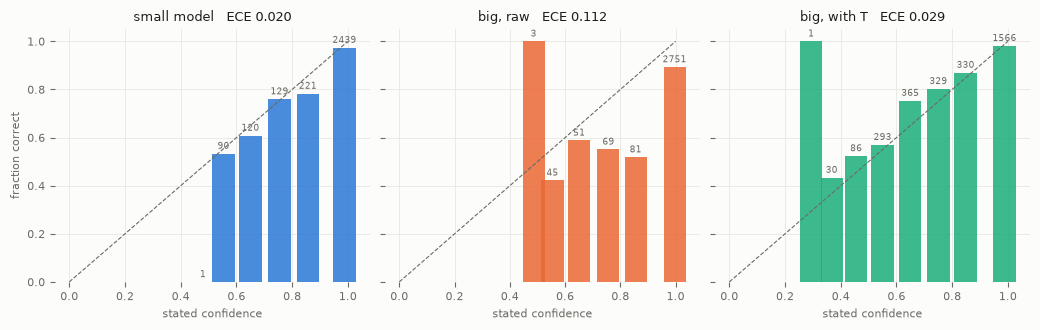

In [17]:
if HAVE_MPL:
    fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.4), sharey=True)
    for ax, (name, pp, col) in zip(axes, [("small model", p_small, BLUE), ("big, raw", p_big_raw, ORANGE), ("big, with T", p_big_T, AQUA)]):
        style(ax)
        rows = reliability(pp, y_big)
        ax.plot([0, 1], [0, 1], color=INK2, lw=0.8, ls="--")
        ax.bar([c for c, _, _ in rows], [h for _, h, _ in rows], width=0.08, color=col, alpha=0.85)
        for c, h, n in rows:
            ax.text(c, h + 0.02, str(n), ha="center", fontsize=6.5, color=INK2)
        ax.set_title(f"{name}   ECE {ece(pp, y_big):.3f}", fontsize=9, color=INK)
        ax.set_xlabel("stated confidence", fontsize=8, color=INK2)
    axes[0].set_ylabel("fraction correct", fontsize=8, color=INK2)
    fig.patch.set_facecolor(SURFACE); plt.tight_layout(); plt.show()
else:
    print("(plot skipped)")

Bars on the diagonal are honest bins; the counts above them say how much of the test set
lives there. The raw big model's bars sit under the line at high confidence — it says 0.95
and is right less often than that — and temperature slides them back.

**The noise floor.** ECE is never zero even for a perfectly honest model, because a bin with
mean confidence 0.6 and 50 items will not be right on exactly 30 of them. Resample labels
*from the model's own probabilities* and measure the ECE a perfectly calibrated model would
show on these predictions. A reported ECE means nothing without it.

In [18]:
def ece_noise_floor(p, reps=200, seed=0):
    g = torch.Generator().manual_seed(seed)
    return float(np.mean([ece(p, torch.multinomial(p, 1, generator=g).squeeze(1)) for _ in range(reps)]))

for name, pp in [("small", p_small), ("big raw", p_big_raw), ("big with T", p_big_T)]:
    print(f"{name:>11}  ECE {ece(pp, y_big):.3f}   floor {ece_noise_floor(pp):.3f}")

      small  ECE 0.020   floor 0.007
    big raw  ECE 0.112   floor 0.005
 big with T  ECE 0.029   floor 0.012


The small model's ECE is a few times its floor: honest, with a little left for a
temperature of its own to fix. The big model's raw ECE is twenty times its floor, and `T`
brings it back to within a couple of floors.

**Coverage at a fixed error budget.** This is the number the product is actually sold on.
Sort decisions by confidence, automate from the top, and stop just before the error rate
among the automated ones would exceed a budget, say 5%. The fraction you automated is the
coverage. It depends only on the *ordering* of confidences across items, which is what
temperature leaves alone: on a two-option question the top probability is a monotone
function of the one logit gap, so `T` cannot reorder anything, and with more options it
can reorder near-ties and nothing else. Measure it on the department question:

In [19]:
def coverage_at(p, y, budget=0.05):
    conf, pred = p.max(-1)
    order = conf.argsort(descending=True)
    wrong = (pred[order] != y[order]).float()
    err = wrong.cumsum(0) / torch.arange(1, len(y) + 1)         # error rate among the top-i most confident
    ok = (err <= budget).nonzero()
    return 0.0 if len(ok) == 0 else (ok.max().item() + 1) / len(y)

def with_confidences(p, conf):
    # keep each row's top answer, give it the confidence `conf`, spread the rest evenly: same answers, new ordering
    top = F.one_hot(p.argmax(-1), p.shape[-1]).float()
    return top * conf[:, None] + (1 - top) * ((1 - conf) / (p.shape[-1] - 1))[:, None]

dept = qtype == 0
perm = torch.randperm(int(dept.sum()), generator=torch.Generator().manual_seed(0))
p_shuffled = with_confidences(p_small[dept], p_small[dept].max(-1).values[perm])

print("coverage at 5% error, department question")
print(f"   small model                          {coverage_at(p_small[dept], y_small[dept]):.3f}")
print(f"   big model, raw                       {coverage_at(p_big_raw[dept], y_big[dept]):.3f}")
print(f"   big model, with T                    {coverage_at(p_big_T[dept], y_big[dept]):.3f}   <- T barely moves it")
print(f"   small model, confidences shuffled    {coverage_at(p_shuffled, y_small[dept]):.3f}   <- same answers, no ordering")

coverage at 5% error, department question
   small model                          0.827
   big model, raw                       0.547
   big model, with T                    0.560   <- T barely moves it
   small model, confidences shuffled    0.002   <- same answers, no ordering


Temperature moved the big model's ECE from 0.11 to 0.03 and its coverage by about one
point, a few near-ties swapping places among four options. Coverage is about which items
the model was *more* sure of, and a rescale keeps that order. Shuffling the confidences
across items, with every answer left in place, sends coverage to zero: same accuracy,
nothing automatable. And the honest small model automates far more than the big one at
the same error budget, with no temperature at all — its ordering came out of training.

This is the measurement behind the one place Jev still leads its open clones: a Kev-9B
that matches Jev on ECE automates half as much traffic at 5% error. ECE can be fixed after
training with one number. Ordering has to come from training — and from the data, which
is the part nobody publishes.

---
## 7. Many questions, one pass

The product promise is that you send one state and many questions, pay for the state
once, and each question is answered as if it were alone. Append a second question to the
sequence and see whether that is true:

In [20]:
t = test_t[7]
orders = {q: list(range(len(OPTIONS[q]))) for q in QNAMES}

def one_pass(model, ticket, qs, isolate=False):
    # several questions after one state. isolate=True builds the block mask and restarted positions.
    # each question's pointer readout uses the </opt> markers of its own block
    state = ["<state>"] + ticket["words"]
    seq, blocks, opt_pos, decides = list(state), [0] * len(state), [], []
    for qi, q in enumerate(qs, start=1):
        qt = question_tokens(q, orders[q])
        opt_pos.append(torch.tensor([[len(seq) + j for j, w in enumerate(qt) if w == "</opt>"] + [-1] * (4 - len(OPTIONS[q]))]))
        seq += qt; blocks += [qi] * len(qt); decides.append(len(seq) - 1)
    ids = torch.tensor([[tok[w] for w in seq]])
    n = len(seq)
    if isolate:
        blk = torch.tensor(blocks)
        allowed = (torch.ones(n, n, dtype=torch.bool).tril() & ((blk[None, :] == 0) | (blk[None, :] == blk[:, None])))[None]
        pos = torch.tensor([i if b == 0 else len(state) + i - blocks.index(b) for i, b in enumerate(blocks)])[None]
    else:
        allowed, pos = None, None
    with torch.no_grad():
        h = model(ids, pos=pos, allowed=allowed)
        return [model.pointer(h, torch.tensor([d]), op).softmax(-1)[0, :len(OPTIONS[q])] for d, op, q in zip(decides, opt_pos, qs)]

alone = {q: one_pass(decider, t, [q])[0] for q in QNAMES}
plain = one_pass(decider, t, QNAMES)
print(" ".join(t["words"]), "\n")
for q, pa, pb in zip(QNAMES, [alone[q] for q in QNAMES], plain):
    print(f"{q:>10}   alone {[round(v, 3) for v in pa.tolist()]}   after the others, plain causal {[round(v, 3) for v in pb.tolist()]}")

error my app and ! ! 

department   alone [0.0, 1.0, 0.0, 0.0]   after the others, plain causal [0.0, 1.0, 0.0, 0.0]
   urgency   alone [0.999, 0.0, 0.001]   after the others, plain causal [0.845, 0.003, 0.151]
     angry   alone [0.013, 0.987]   after the others, plain causal [0.958, 0.042]


The department question is unchanged — it comes first and sees only the state. The urgency
and angry answers moved. With a plain causal mask the second question reads the first
question's tokens, and the third reads both; the answer now depends on what else you asked,
which breaks the promise and also wastes the model's attention on tokens that are not
evidence.

The fix is a mask with the shape of the request. Each question may look at the state and
at itself, and at nothing else; and each question's position ids restart right after the
state, so a question looks the same to the model whether it is first or fifth:

In [21]:
isolated = one_pass(decider, t, QNAMES, isolate=True)
for q, pa, pb in zip(QNAMES, [alone[q] for q in QNAMES], isolated):
    print(f"{q:>10}   alone {[round(v, 3) for v in pa.tolist()]}   in one pass, block mask {[round(v, 3) for v in pb.tolist()]}   same: {torch.allclose(pa, pb, atol=1e-5)}")

# the mask itself, for a short state and two two-option questions
state_n, q_n = 3, 6
blocks = [0] * state_n + [1] * q_n + [2] * q_n
blk = torch.tensor(blocks); n = len(blocks)
allowed = torch.ones(n, n, dtype=torch.bool).tril() & ((blk[None, :] == 0) | (blk[None, :] == blk[:, None]))
print("\nrows = queries, columns = keys; S = state, 1/2 = question blocks")
print("     " + "".join("S" if b == 0 else str(b) for b in blocks))
for i in range(n):
    print(f"{'S' if blocks[i] == 0 else blocks[i]:>3}  " + "".join("#" if allowed[i, j] else "." for j in range(n)))

department   alone [0.0, 1.0, 0.0, 0.0]   in one pass, block mask [0.0, 1.0, 0.0, 0.0]   same: True
   urgency   alone [0.999, 0.0, 0.001]   in one pass, block mask [0.999, 0.0, 0.001]   same: True
     angry   alone [0.013, 0.987]   in one pass, block mask [0.013, 0.987]   same: True

rows = queries, columns = keys; S = state, 1/2 = question blocks
     SSS111111222222
  S  #..............
  S  ##.............
  S  ###............
  1  ####...........
  1  #####..........
  1  ######.........
  1  #######........
  1  ########.......
  1  #########......
  2  ###......#.....
  2  ###......##....
  2  ###......###...
  2  ###......####..
  2  ###......#####.
  2  ###......######


Identical to float tolerance, three questions in one forward pass, the state encoded
once. In question 2's rows the columns under question 1 are empty: it cannot see it. That
staircase is the entire architectural content of "parallel questions", and it is the one
piece of the decision model that has to touch the attention code. In the repo it is a
mask rule on `full_attention`, the same seam the sliding window uses.

Two things this buys at scale. Adding a question adds a short block, not a second prefill
over the state, which is why Jev answers 1,500 questions in under 600 ms. And a question
cannot be steered by text planted in a sibling question, only by the state — which is
testable: plant a code in question 1's option text, ask question 2 about it, and expect
nothing.

---
## 8. The other readout, and the order of the options

There is a second way to read a decision off a transformer, and it is the one most
two-hour reproductions used: give each option a one-token label, `A`, `B`, `C`, and read
the *LM head's* logits for those tokens at `<decide>`. No new parameters.

```
<q> department A billing B technical C account D other <decide>
```

The model's job is now different. Instead of "which option's hidden state matches the
decision?", which is a dot product, it has to learn "which *letter* preceded the option
that matches?", which is a copy through two hops of attention. Same backbone, same data.
First, six epochs each — a quarter of what the main model got:

In [22]:
def question_tokens_labels(q, order):
    out = ["<q>", q]
    for label, j in zip(LABELS, order):
        out += [label, OPTIONS[q][j]]
    return out + ["<decide>"]

def records_labels(tickets, rng, shuffle_options=True):
    out = []
    for t in tickets:
        for q in QNAMES:
            order = list(range(len(OPTIONS[q])))
            if shuffle_options:
                rng.shuffle(order)
            out.append((["<state>"] + t["words"] + question_tokens_labels(q, order), len(order), order.index(t["label"][q])))
    return out

LABEL_IDS = torch.tensor([tok[c] for c in LABELS])

def readout_labels(model, h, decide, k, ids):
    at = h[torch.arange(len(decide)), decide]                   # the hidden state at each <decide>
    logits = model.lm_head(at)[:, LABEL_IDS]                    # only the label tokens' logits
    valid = torch.arange(4)[None] < k[:, None]                  # the first k labels exist for this question
    return logits.masked_fill(~valid, float("-inf"))

label_train, label_test = records_labels(train_t, random.Random(1)), records_labels(test_t, random.Random(2))

def department_accuracy(model, recs, readout):
    p, y = predict(model, recs, readout)
    return (p.argmax(-1) == y).float()[torch.arange(len(recs)) % 3 == 0].mean().item()

torch.manual_seed(0); pointer_6 = train(new_decider(), train_recs, readout_pointer, epochs=6, verbose=False)
torch.manual_seed(0); labels_6 = train(Backbone(len(VOCAB)), label_train, readout_labels, epochs=6, verbose=False)
print(f"department accuracy after 6 epochs    pointer head {department_accuracy(pointer_6, test_recs, readout_pointer):.3f}   label tokens {department_accuracy(labels_6, label_test, readout_labels):.3f}")

department accuracy after 6 epochs    pointer head 0.841   label tokens 0.286


After six epochs the pointer head has the department question and the label readout is at
chance on it: pointing is a dot product the head can learn almost immediately, while
copying the right letter has to be assembled across two layers of attention first. Give
the label readout the full twenty-five epochs and it catches up on this task:

In [23]:
torch.manual_seed(0)
labeller = train(Backbone(len(VOCAB)), label_train, readout_labels, verbose=False)
p_lab, y_lab = predict(labeller, label_test, readout_labels)
acc_lab = (p_lab.argmax(-1) == y_lab).float()
for i, q in enumerate(QNAMES):
    print(f"{q:>10}  accuracy after 25 epochs   pointer head {acc[qtype == i].mean():.3f}   label tokens {acc_lab[qtype == i].mean():.3f}")

department  accuracy after 25 epochs   pointer head 0.883   label tokens 0.886
   urgency  accuracy after 25 epochs   pointer head 1.000   label tokens 1.000
     angry  accuracy after 25 epochs   pointer head 0.884   label tokens 0.903


Level on four options. The differences are elsewhere. The label readout needs one single
token per option, so it runs out at the number of labels you have — Jebadiah stops at 68,
Banking77 has 77 intents — and the model has to learn what `C` means today. The pointer
head never names the answer, only points at it, and does not care how many options there
are. The open models that use labels sit on backbones with billions of parameters, where
the copy is free; the ones built for many options, Clef and Strands Decider, use a head.

What the pointer head pays for being listwise is the thing Jev's own documentation admits
to: **the order of the options can affect the answer**. Measure it rather than assume it.
Re-draw the option order on every test ticket and count how often the top answer changes:

In [24]:
def top_option(rec, p):
    # map the winning slot back to the option name it held
    seq = rec[0]; q = seq[seq.index("<q>") + 1]
    names = [w for w in seq[seq.index("<q>") + 2:] if w in OPTIONS[q]]
    return names[p.argmax().item()]

def flip_rate(model, tickets, make_recs, readout, seed=5):
    # the department question only: make_recs returns (department, urgency, angry) per ticket, so take [0]
    rng_a, rng_b = random.Random(seed), random.Random(seed + 1)
    flips, confs = 0, []
    for t in tickets:
        rec_a, rec_b = make_recs([t], rng_a)[0], make_recs([t], rng_b)[0]           # same ticket, two option orders
        pa, _ = predict(model, [rec_a], readout); pb, _ = predict(model, [rec_b], readout)
        if top_option(rec_a, pa) != top_option(rec_b, pb):
            flips += 1; confs.append(pa.max().item())
    return flips / len(tickets), (float(np.mean(confs)) if confs else float("nan"))

rate, mean_conf = flip_rate(decider, test_t[:300], records, readout_pointer)
print(f"pointer head: the top department flips on {rate:.1%} of tickets when the options are re-ordered")
print(f"              mean confidence of the flipped ones {mean_conf:.2f}, against {p_small[qtype == 0].max(-1).values.mean():.2f} over all department answers")

pointer head: the top department flips on 6.7% of tickets when the options are re-ordered
              mean confidence of the flipped ones 0.66, against 0.92 over all department answers


A few percent, and the flips sit where the model was least sure, which is the benign case:
it was torn and the order broke the tie. Jev 1.13 "leans toward the option that comes
first"; this model was trained with the order shuffled on every record, which is what keeps
the lean small. The malign case is a model trained with the options always in the same
order. It learns the *slot*, not the option:

In [25]:
torch.manual_seed(0)
fixed = train(new_decider(), records(train_t, random.Random(1), shuffle_options=False), readout_pointer, epochs=6, verbose=False)
p_ff, y_ff = predict(fixed, records(test_t, random.Random(2), shuffle_options=False), readout_pointer)
p_fs, y_fs = predict(fixed, records(test_t, random.Random(2), shuffle_options=True), readout_pointer)
print(f"trained with options in a fixed order:   tested in the same order {(p_ff.argmax(-1) == y_ff).float().mean():.3f}   tested shuffled {(p_fs.argmax(-1) == y_fs).float().mean():.3f}")

trained with options in a fixed order:   tested in the same order 0.918   tested shuffled 0.476


Near-perfect in the order it was trained on, halved the moment the options move: the
pointer learned "the answer is usually the first `</opt>`", never what stood between the
markers. Six epochs were enough to learn that; it is the easier lesson. The generator in
section 2 shuffled on every record, which is why the first model survived the same test.
That is the "permute field orders and schemas" line in Clef's training description, and
the "shuffle option order at pack time" line in the repo's roadmap.

---
## What to remember

| what | why |
|---|---|
| a decision is the first step of generation with the loop removed | one prefill, read the logits at one position, stop |
| softmax only over the allowed answers | the schema is closed by construction; "zero hallucination" means exactly this |
| `score` and `confidence` are arithmetic on the distribution | the model outputs probabilities; everything else is a formula you can check |
| honest = reports the frequency of the data it cannot tell apart | there is no "be 60% sure" label; the collection carries the number |
| a proper scoring rule has its maximum at the frequency | Brier and log score do; "1 if correct" does not — that difference is RLCD |
| the RL phrasing reaches the same place as the supervised one | sampling a probability plus a proper reward equals the loss; sampling an answer plus accuracy does not |
| cleaned labels make a model confidently wrong | ambiguity in the data is the signal, not noise |
| capacity plus epochs push probabilities to 0 and 1 | fit a temperature per primitive on held-out data, always |
| temperature is monotone | it fixes ECE and cannot touch ordering; measure coverage at a fixed error budget |
| questions must not see each other | a block mask plus restarted positions makes k questions in one pass equal k passes |
| a pointer head points, a label readout copies | pointing is learned in a few epochs; copying a letter takes longer, and runs out of letters |
| shuffle the options in training | or the model learns the slot, and collapses when the options move |

The traps here are the quiet kind. The cleaned-label model has the same accuracy as the
honest one. The overtrained model has a *better* training loss and an honest-looking mean.
The fixed-order model scores higher on its own test split. Each one is found only by a
check that asks about the number, not the answer: the generator's truth, the held-out
reliability diagram, the shuffled options.

---

## Exercises

1. **Ordinal targets.** The score question treats "one level off" and "two levels off" as
   equally wrong. Give the target 0.2 of its mass to the adjacent levels (Jebadiah's kernel)
   and check whether the model's score distributions get smoother *and* whether ECE on the
   score question moves.
2. **The unanswerable question.** Add a fourth question whose label depends on something the
   state never contains — a policy flag the generator rolls but does not write into the
   words. The honest answer is the base rate. Does the small model say so? Does the big one?
3. **Plant a code.** Put a six-letter code in question 1's option text and ask question 2
   whether the state contains it. With the block mask the answer must be no; without it,
   see what happens.
4. **Equal-mass bins.** Rewrite `ece` with bins that hold equal counts instead of equal
   widths and compare the two numbers on the big raw model. Which one is closer to its
   noise floor, and why does the choice matter when most predictions sit above 0.9?
5. **Partial credit as RL.** Implement Clef's reward — full credit for the right score level,
   half for an adjacent one — as a REINFORCE stage after the supervised training, using
   `reinforce` from section 4 as the template, and report ECE and coverage before and after.
   This is the repo's roadmap step 4, on a toy.
6. **Make it real.** Replace `Backbone` with a pretrained causal model loaded through
   `transformers`, keep `PointerHead`, `readout_pointer`, the block mask and `train`
   unchanged, and pass the mask as a 4-D attention mask with `position_ids`. The isolation
   test in section 7 must still pass before any training. That is the whole of the
   roadmap's step 2.